# Assignment 1 — Build a Custom Missing-Value Imputer

**Course:** Feature Engineering & MLOps  
**Assignment:** 1  
**Topic:** Custom Imputer Class (Missing Value Handling)  
**Dataset:** `student_performance_raw.csv`

## Objective

The goal of this assignment is to design and implement a custom Python imputer that follows the same **`fit()` / `transform()` pattern** used by scikit-learn transformers. The imputer must:

- inherit from `BaseEstimator` and `TransformerMixin`;
- automatically detect numeric and non-numeric columns;
- learn fill values using **training data only**;
- use mean/median for numeric columns and most-frequent value for non-numeric columns;
- optionally create missing-value indicator features;
- prevent `transform()` from being called before `fit()`;
- provide clear docstrings and fitted attributes;
- be verified against scikit-learn's `SimpleImputer`;
- demonstrate the optional **per-column strategy override** bonus.

> **Assignment source:** The provided assignment PDF specifies the required class API, train/test discipline, verification checks, reflection questions, and optional bonus. The dataset is the provided PrepEdge `student_performance_raw.csv`.


## 1. Assignment Requirements Checklist

The notebook below implements all required components from the assignment:

1. `CustomImputer(BaseEstimator, TransformerMixin)`
2. Constructor parameters:
   - `numeric_strategy='median'`
   - `categorical_strategy='most_frequent'`
   - `add_missing_indicator=True`
   - bonus: `column_overrides=None`
3. `fit(X, y=None)` learns and stores `fill_values_`.
4. `transform(X)` returns a copy and never recalculates training statistics.
5. Automatic numeric/non-numeric detection.
6. Missing indicators named `<column>_was_missing`.
7. `check_is_fitted()` guard rail.
8. Train/test split of 80/20.
9. Fit **only on training data**.
10. Transform both train and test.
11. Programmatic missing-value verification.
12. Before/after numeric mean and standard deviation comparison.
13. Comparison with scikit-learn `SimpleImputer`.
14. Three reflection answers.
15. Bonus: per-column strategy overrides demonstrated on at least two columns with different strategies.


In [ ]:
# Core imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("Imports completed successfully.")


Imports completed successfully.


## 2. Load the Dataset

The assignment specifies `data/raw/student_performance_raw.csv`. The path resolver below first looks for the repository-style location and then falls back to the uploaded file location used in this notebook environment.

This makes the notebook easier to reuse after placing it in the required `Assignments/` folder in the GitHub repository.


In [ ]:
# Resolve the dataset path in both repository and notebook environments
candidate_paths = [
    Path("../data/raw/student_performance_raw.csv"),   # notebook inside Assignments/
    Path("data/raw/student_performance_raw.csv"),      # notebook run from repository root
    Path("/mnt/data/student_performance_raw.csv"),      # uploaded file in this environment
    Path("student_performance_raw.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "student_performance_raw.csv was not found. "
        "Place it at data/raw/student_performance_raw.csv or upload the dataset."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())


Dataset path: /mnt/data/student_performance_raw.csv
Shape: 600 rows × 17 columns


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.100,0.800,<5L,65.200,68.100,59.000,72.200,1,Need more practice sheets for weak topics,42.000
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.900,2.400,NaN,64.900,82.000,88.400,100.000,3,Would like more one-on-one mentoring,62.000
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.100,6.700,5-10L,90.100,86.500,91.100,76.400,5,"Great teaching pace, doubts cleared quickly",56.400
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.700,2.000,10-20L,29.700,19.400,24.900,NaN,3,Need more practice sheets for weak topics,31.700
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.300,6.500,>20L,70.000,63.800,74.500,69.100,4,Need more practice sheets for weak topics,44.500


### 2.1 Dataset Structure and Missing Values

The assignment PDF identifies missingness in:

- `weekly_study_hours` — numeric, MCAR
- `prev_exam_score` — numeric, MAR linked to `attendance_pct`
- `mock_test_3` — numeric, MNAR linked to its own low values
- `income_bracket` — categorical
- `feedback_text` — text

The dataset also contains other columns that are complete. The custom imputer will inspect every column automatically.


In [ ]:
# Data types and missing-value profile
print("Data types:")
display(df.dtypes.to_frame("dtype"))

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

print("Columns containing missing values:")
display(missing_summary)

print(f"Total missing cells: {int(df.isna().sum().sum())}")


Data types:


,dtype
student_id,int64
city,object
city_tier,int64
course,object
batch_type,object
age,int64
enrollment_date,object
attendance_pct,float64
weekly_study_hours,float64
income_bracket,object


Columns containing missing values:


,missing_count,missing_pct,dtype
feedback_text,68,11.330,object
weekly_study_hours,36,6.000,float64
income_bracket,30,5.000,object
prev_exam_score,25,4.170,float64
mock_test_3,21,3.500,float64


Total missing cells: 180


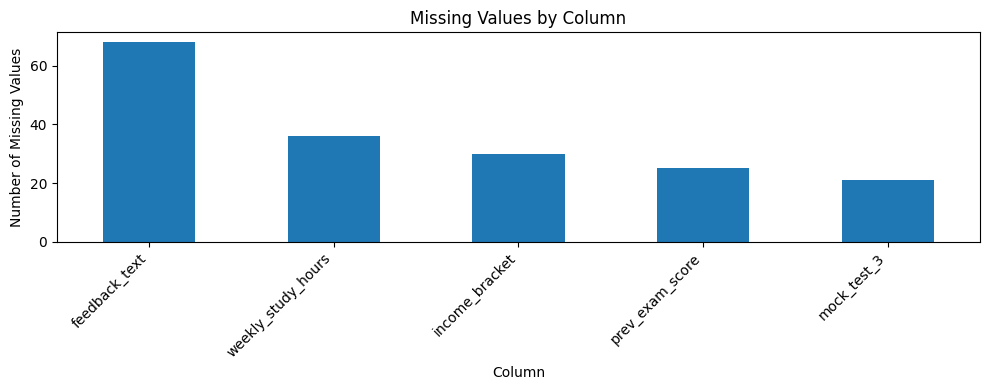

In [ ]:
# Quick visual check of missing-value counts
if not missing_summary.empty:
    ax = missing_summary["missing_count"].plot(kind="bar", figsize=(10, 4))
    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Column")
    ax.set_ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 3. Train/Test Split — Preventing Data Leakage

The assignment requires an **80% training / 20% testing split**. The custom imputer must be fitted only on the training set.

This is important because the learned statistics (mean, median, or mode) are information derived from data. Using the test set to calculate them would leak information from the evaluation data into the preprocessing stage.


In [ ]:
# 80/20 split as required by the assignment
X_train, X_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")
print(f"Training proportion: {len(X_train) / len(df):.1%}")
print(f"Testing proportion:  {len(X_test) / len(df):.1%}")


Training set shape: (480, 17)
Testing set shape:  (120, 17)
Training proportion: 80.0%
Testing proportion:  20.0%


## 4. CustomImputer Class

The class below is the main deliverable.

### Design decisions

- **Numeric columns:** use `mean` or `median`.
- **Non-numeric columns:** use `most_frequent`.
- **Missing indicators:** created only for columns that had at least one missing value during `fit()`.
- **Fitted statistics:** stored in `self.fill_values_`.
- **Column types:** stored in `self.column_types_`.
- **Training feature names:** stored in `self.feature_names_in_`.
- **Guard rail:** `transform()` uses `check_is_fitted()` and raises an informative error if `fit()` has not been called.
- **Bonus:** `column_overrides` allows a particular column to use a different strategy from the dataset-wide default.

A completely missing training column has no mean/median/mode. This implementation records `NaN` for that case rather than inventing a statistic; the limitation is discussed in Reflection Question 3.


In [ ]:
class CustomImputer(BaseEstimator, TransformerMixin):
    """
    Custom missing-value imputer following the scikit-learn estimator API.

    Parameters
    ----------
    numeric_strategy : str, default='median'
        Strategy for numeric columns. Allowed values are 'mean' and 'median'.

    categorical_strategy : str, default='most_frequent'
        Strategy for non-numeric columns. The assignment requires
        'most_frequent'. This parameter is kept explicit so the behavior
        is clear and scikit-learn compatible.

    add_missing_indicator : bool, default=True
        If True, add a binary '<column>_was_missing' feature for every
        column that contained at least one missing value during fit().

    column_overrides : dict or None, default=None
        Optional per-column strategy overrides. Example:
        {'weekly_study_hours': 'mean', 'income_bracket': 'most_frequent'}.

    Attributes
    ----------
    fill_values_ : dict
        Learned fill value for every input column.

    column_types_ : dict
        Automatically detected type ('numeric' or 'categorical') for
        every input column.

    missing_indicator_columns_ : list
        Columns that had at least one missing value in the training data.

    feature_names_in_ : list
        Input columns seen during fit().
    """

    def __init__(
        self,
        numeric_strategy="median",
        categorical_strategy="most_frequent",
        add_missing_indicator=True,
        column_overrides=None,
    ):
        """
        Initialize the custom imputer.

        Parameters
        ----------
        numeric_strategy : str
            Default strategy for numeric columns: 'mean' or 'median'.

        categorical_strategy : str
            Strategy for non-numeric columns. Must be 'most_frequent'.

        add_missing_indicator : bool
            Whether to add missing-value indicator columns.

        column_overrides : dict or None
            Optional mapping of column names to their individual strategies.

        Returns
        -------
        None
            Constructor initializes the estimator.
        """
        self.numeric_strategy = numeric_strategy
        self.categorical_strategy = categorical_strategy
        self.add_missing_indicator = add_missing_indicator
        self.column_overrides = column_overrides

    def _validate_strategies(self):
        """Validate the configured imputation strategies."""
        if self.numeric_strategy not in {"mean", "median"}:
            raise ValueError(
                "numeric_strategy must be either 'mean' or 'median'."
            )

        if self.categorical_strategy != "most_frequent":
            raise ValueError(
                "categorical_strategy must be 'most_frequent' for this assignment."
            )

        if self.column_overrides is not None and not isinstance(self.column_overrides, dict):
            raise TypeError("column_overrides must be a dictionary or None.")

        if self.column_overrides:
            allowed = {"mean", "median", "most_frequent"}
            invalid = {
                col: strategy
                for col, strategy in self.column_overrides.items()
                if strategy not in allowed
            }
            if invalid:
                raise ValueError(
                    f"Invalid override strategies: {invalid}. "
                    f"Allowed values are {sorted(allowed)}."
                )

    def _get_strategy(self, column):
        """Return the effective strategy for one column."""
        if self.column_overrides and column in self.column_overrides:
            return self.column_overrides[column]

        if self.column_types_[column] == "numeric":
            return self.numeric_strategy

        return self.categorical_strategy

    def fit(self, X, y=None):
        """
        Learn missing-value fill statistics from X.

        Parameters
        ----------
        X : pandas.DataFrame
            Training data used to learn imputation statistics.

        y : array-like or None, default=None
            Ignored. Present for scikit-learn estimator API compatibility.

        Returns
        -------
        self
            Fitted CustomImputer instance.
        """
        self._validate_strategies()

        if not isinstance(X, pd.DataFrame):
            raise TypeError("CustomImputer.fit() expects X to be a pandas DataFrame.")

        if X.columns.duplicated().any():
            duplicated = X.columns[X.columns.duplicated()].tolist()
            raise ValueError(
                f"Input contains duplicate column names: {duplicated}"
            )

        if X.shape[1] == 0:
            raise ValueError("X must contain at least one column.")

        self.feature_names_in_ = list(X.columns)
        self.column_types_ = {
            column: (
                "numeric"
                if pd.api.types.is_numeric_dtype(X[column])
                else "categorical"
            )
            for column in X.columns
        }

        self.missing_indicator_columns_ = [
            column for column in X.columns if X[column].isna().any()
        ]

        self.fill_values_ = {}
        self.strategies_ = {}

        for column in X.columns:
            strategy = self._get_strategy(column)
            self.strategies_[column] = strategy

            series = X[column]

            if strategy in {"mean", "median"}:
                if not pd.api.types.is_numeric_dtype(series):
                    raise TypeError(
                        f"Strategy '{strategy}' requires a numeric column. "
                        f"Column '{column}' is non-numeric."
                    )

                if series.dropna().empty:
                    # No statistic exists when every training value is missing.
                    self.fill_values_[column] = np.nan
                elif strategy == "mean":
                    self.fill_values_[column] = series.mean()
                else:
                    self.fill_values_[column] = series.median()

            elif strategy == "most_frequent":
                non_missing = series.dropna()

                if non_missing.empty:
                    # No mode exists for a completely missing training column.
                    self.fill_values_[column] = np.nan
                else:
                    self.fill_values_[column] = non_missing.mode(dropna=True).iloc[0]

        return self

    def transform(self, X):
        """
        Impute missing values in X using statistics learned during fit().

        Parameters
        ----------
        X : pandas.DataFrame
            Data to transform. It must contain the same input columns seen
            during fit().

        Returns
        -------
        pandas.DataFrame
            A copy of X with missing values imputed and, when enabled,
            missing-value indicator columns appended.
        """
        check_is_fitted(
            self,
            attributes=[
                "fill_values_",
                "feature_names_in_",
                "missing_indicator_columns_",
            ],
        )

        if not isinstance(X, pd.DataFrame):
            raise TypeError("CustomImputer.transform() expects X to be a pandas DataFrame.")

        missing_columns = [
            column for column in self.feature_names_in_ if column not in X.columns
        ]
        if missing_columns:
            raise ValueError(
                f"Transform data is missing columns seen during fit: {missing_columns}"
            )

        extra_columns = [column for column in X.columns if column not in self.feature_names_in_]
        if extra_columns:
            raise ValueError(
                f"Transform data contains unseen columns not present during fit: {extra_columns}"
            )

        # Reorder to exactly match the training schema.
        X_transformed = X.loc[:, self.feature_names_in_].copy()

        # Capture indicators BEFORE filling values.
        if self.add_missing_indicator:
            for column in self.missing_indicator_columns_:
                indicator_name = f"{column}_was_missing"

                if indicator_name in X_transformed.columns:
                    raise ValueError(
                        f"Indicator column name '{indicator_name}' already exists."
                    )

                X_transformed[indicator_name] = (
                    X_transformed[column].isna().astype("int8")
                )

        # Apply ONLY the values learned during fit().
        for column, fill_value in self.fill_values_.items():
            if pd.isna(fill_value):
                # Deliberately leave an all-missing training column unresolved.
                # Reflection Q3 discusses the production-grade alternative.
                continue

            X_transformed[column] = X_transformed[column].fillna(fill_value)

        return X_transformed


## 5. Unit Test: `transform()` Before `fit()`

The assignment specifically requires a guard rail. We verify that calling `transform()` before fitting raises a clear error.


In [ ]:
# Guard-rail test
unfitted_imputer = CustomImputer()

try:
    unfitted_imputer.transform(X_train)
    raise AssertionError("Expected transform() to fail before fit().")
except Exception as error:
    print("Guard-rail passed.")
    print("Error type:", type(error).__name__)
    print("Message:", str(error))


Guard-rail passed.
Error type: NotFittedError
Message: This CustomImputer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


## 6. Fit the Custom Imputer on TRAINING Data Only

The default configuration uses:

- numeric columns → **median**
- non-numeric columns → **most frequent**
- missing indicators → **enabled**

The fitted statistics shown below are calculated exclusively from `X_train`.


In [ ]:
custom_imputer = CustomImputer(
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_missing_indicator=True,
)

# IMPORTANT: fit ONLY on training data
custom_imputer.fit(X_train)

print("CustomImputer fitted successfully.")


CustomImputer fitted successfully.


In [ ]:
# Inspect what the model learned during fit()
fit_summary = pd.DataFrame({
    "column": custom_imputer.feature_names_in_,
    "detected_type": [custom_imputer.column_types_[c] for c in custom_imputer.feature_names_in_],
    "strategy": [custom_imputer.strategies_[c] for c in custom_imputer.feature_names_in_],
    "fill_value": [custom_imputer.fill_values_[c] for c in custom_imputer.feature_names_in_],
    "had_missing_in_train": [
        c in custom_imputer.missing_indicator_columns_
        for c in custom_imputer.feature_names_in_
    ],
})

display(fit_summary)

print("Columns receiving missing indicators:")
print(custom_imputer.missing_indicator_columns_)


,column,detected_type,strategy,fill_value,had_missing_in_train
0,student_id,numeric,median,1282.000,False
1,city,categorical,most_frequent,Mumbai,False
2,city_tier,numeric,median,1.000,False
3,course,categorical,most_frequent,NEET,False
4,batch_type,categorical,most_frequent,Weekday,False
5,age,numeric,median,17.000,False
6,enrollment_date,categorical,most_frequent,2024-10-23,False
7,attendance_pct,numeric,median,78.350,False
8,weekly_study_hours,numeric,median,5.000,True
9,income_bracket,categorical,most_frequent,5-10L,True


Columns receiving missing indicators:
['weekly_study_hours', 'income_bracket', 'prev_exam_score', 'mock_test_3', 'feedback_text']


## 7. Transform BOTH Training and Test Data

The same fitted statistics are now used for both splits. No statistic is recomputed inside `transform()`.

The indicator columns are based on whether each row was missing **before** imputation.


In [ ]:
X_train_imputed = custom_imputer.transform(X_train)
X_test_imputed = custom_imputer.transform(X_test)

print("Original training shape:", X_train.shape)
print("Imputed training shape: ", X_train_imputed.shape)
print("Original testing shape: ", X_test.shape)
print("Imputed testing shape:  ", X_test_imputed.shape)

display(X_train_imputed.head())


Original training shape: (480, 17)
Imputed training shape:  (480, 22)
Original testing shape:  (120, 17)
Imputed testing shape:   (120, 22)


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score,weekly_study_hours_was_missing,income_bracket_was_missing,prev_exam_score_was_missing,mock_test_3_was_missing,feedback_text_was_missing
0,1551,Pune,1,JEE Main,Weekend,17,2024-12-17,59.800,2.000,5-10L,56.500,58.300,46.200,54.500,5,Would like more one-on-one mentoring,39.300,0,0,0,0,0
1,1166,Kota,2,JEE Main,Weekday,15,2025-08-19,72.900,5.000,10-20L,57.800,46.600,40.900,34.900,6,Need more practice sheets for weak topics,43.200,1,0,0,0,0
2,1367,Hyderabad,2,Foundation,Weekday,17,2026-02-14,72.100,6.200,5-10L,45.100,52.000,59.100,65.900,1,Need more practice sheets for weak topics,44.000,0,0,0,0,0
3,1562,Delhi,1,NEET,Weekday,19,2025-10-04,82.500,1.100,5-10L,54.300,58.700,63.800,74.000,4,Mock tests really helped identify gaps,39.600,0,0,0,0,0
4,1575,Lucknow,2,NEET,Weekend,15,2025-05-29,98.000,2.800,<5L,78.800,73.800,78.600,87.900,3,"Great teaching pace, doubts cleared quickly",55.000,0,0,0,0,0


## 8. Verification — No Missing Values Remain in Imputed Columns

The required programmatic verification is performed below.

We verify:
1. every original column with missing values in the training set has no missing values after transformation;
2. the same relevant columns have no missing values in the transformed test set;
3. every generated indicator is binary (`0`/`1`).


In [ ]:
# Columns that the imputer was required to repair
imputed_columns = custom_imputer.missing_indicator_columns_

train_remaining = X_train_imputed[imputed_columns].isna().sum()
test_remaining = X_test_imputed[imputed_columns].isna().sum()

print("Remaining missing values in imputed training columns:")
display(train_remaining.to_frame("missing_count"))

print("Remaining missing values in imputed testing columns:")
display(test_remaining.to_frame("missing_count"))

assert train_remaining.sum() == 0, "Training data still contains missing values in imputed columns."
assert test_remaining.sum() == 0, "Test data still contains missing values in imputed columns."

# Verify all generated indicators are binary
indicator_columns = [f"{c}_was_missing" for c in imputed_columns]

for column in indicator_columns:
    unique_values = set(X_train_imputed[column].dropna().unique())
    assert unique_values.issubset({0, 1}), f"{column} is not binary."

print("PASS: No missing values remain in the imputed columns.")
print("PASS: All missing indicators are binary.")


Remaining missing values in imputed training columns:


,missing_count
weekly_study_hours,0
income_bracket,0
prev_exam_score,0
mock_test_3,0
feedback_text,0


Remaining missing values in imputed testing columns:


,missing_count
weekly_study_hours,0
income_bracket,0
prev_exam_score,0
mock_test_3,0
feedback_text,0


PASS: No missing values remain in the imputed columns.
PASS: All missing indicators are binary.


### 8.1 Missing Indicator Sanity Check

For each training column with missing values, the indicator should contain `1` exactly where the original training value was missing.


In [ ]:
indicator_check = []

for column in imputed_columns:
    expected = X_train[column].isna().astype("int8").reset_index(drop=True)
    actual = X_train_imputed[f"{column}_was_missing"].reset_index(drop=True)

    indicator_check.append({
        "column": column,
        "original_missing_count": int(expected.sum()),
        "indicator_ones": int(actual.sum()),
        "matches_original_missingness": bool(expected.equals(actual)),
    })

indicator_check_df = pd.DataFrame(indicator_check)
display(indicator_check_df)

assert indicator_check_df["matches_original_missingness"].all()
print("PASS: Missing indicators correctly record the original missingness pattern.")


,column,original_missing_count,indicator_ones,matches_original_missingness
0,weekly_study_hours,25,25,True
1,income_bracket,24,24,True
2,prev_exam_score,23,23,True
3,mock_test_3,15,15,True
4,feedback_text,54,54,True


PASS: Missing indicators correctly record the original missingness pattern.


## 9. Numeric Statistics BEFORE vs AFTER Imputation

The assignment asks for the mean and standard deviation of each numeric column before and after imputation.

Because the imputer is fitted on training data only, the primary comparison below uses the **training split**. A second table also reports the corresponding test-set statistics for completeness.

Columns without missing values should remain unchanged. Columns that receive median imputation can show a change in their distribution because missing entries are replaced by the training median.


In [ ]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()

train_numeric_stats = pd.DataFrame({
    "mean_before": X_train[numeric_columns].mean(),
    "std_before": X_train[numeric_columns].std(),
    "mean_after": X_train_imputed[numeric_columns].mean(),
    "std_after": X_train_imputed[numeric_columns].std(),
})

train_numeric_stats["mean_change"] = (
    train_numeric_stats["mean_after"] - train_numeric_stats["mean_before"]
)
train_numeric_stats["std_change"] = (
    train_numeric_stats["std_after"] - train_numeric_stats["std_before"]
)

print("Training-set numeric statistics:")
display(train_numeric_stats.round(4))


Training-set numeric statistics:


,mean_before,std_before,mean_after,std_after,mean_change,std_change
student_id,1290.562,173.825,1290.562,173.825,0.000,0.000
city_tier,1.402,0.491,1.402,0.491,0.000,0.000
age,16.956,1.732,16.956,1.732,0.000,0.000
attendance_pct,78.546,13.460,78.546,13.460,0.000,0.000
weekly_study_hours,6.064,4.350,6.009,4.242,-0.055,-0.108
prev_exam_score,65.825,14.371,65.838,14.022,0.013,-0.349
mock_test_1,65.945,16.566,65.945,16.566,0.000,0.000
mock_test_2,67.886,18.109,67.886,18.109,0.000,0.000
mock_test_3,70.701,19.077,70.720,18.776,0.019,-0.301
doubt_sessions_attended,4.004,2.026,4.004,2.026,0.000,0.000


In [ ]:
test_numeric_stats = pd.DataFrame({
    "mean_before": X_test[numeric_columns].mean(),
    "std_before": X_test[numeric_columns].std(),
    "mean_after": X_test_imputed[numeric_columns].mean(),
    "std_after": X_test_imputed[numeric_columns].std(),
})

test_numeric_stats["mean_change"] = (
    test_numeric_stats["mean_after"] - test_numeric_stats["mean_before"]
)
test_numeric_stats["std_change"] = (
    test_numeric_stats["std_after"] - test_numeric_stats["std_before"]
)

print("Test-set numeric statistics:")
display(test_numeric_stats.round(4))


Test-set numeric statistics:


,mean_before,std_before,mean_after,std_after,mean_change,std_change
student_id,1340.250,166.270,1340.250,166.270,0.000,0.000
city_tier,1.350,0.479,1.350,0.479,0.000,0.000
age,17.075,1.070,17.075,1.070,0.000,0.000
attendance_pct,76.511,14.915,76.511,14.915,0.000,0.000
weekly_study_hours,5.593,3.705,5.538,3.534,-0.054,-0.171
prev_exam_score,64.500,15.475,64.527,15.346,0.027,-0.129
mock_test_1,65.431,17.004,65.431,17.004,0.000,0.000
mock_test_2,67.914,17.892,67.914,17.892,0.000,0.000
mock_test_3,72.097,16.768,72.057,16.341,-0.040,-0.427
doubt_sessions_attended,3.858,2.112,3.858,2.112,0.000,0.000


### Comment on the Changes

For columns that originally had no missing values, the before/after statistics are identical because the imputer does not alter observed values.

For columns with missing values, the mean and standard deviation can change because missing observations are replaced with a single learned statistic. With median imputation, the inserted values are concentrated at the training median, which generally reduces variability compared with the original observed-only distribution. The exact changes are shown in the tables above.


## 10. Sanity Check Against `SimpleImputer`

The assignment asks us to confirm that the custom class produces the same fill values as scikit-learn's `SimpleImputer` on the same numeric columns.

Because the default `CustomImputer` uses **median** for numeric data, we configure `SimpleImputer(strategy='median')` and fit it on exactly the same `X_train[numeric_columns]`.


In [ ]:
# Equivalent sklearn implementation for numeric columns
numeric_simple_imputer = SimpleImputer(strategy="median")

numeric_simple_imputer.fit(X_train[numeric_columns])

sklearn_fill_values = dict(
    zip(numeric_columns, numeric_simple_imputer.statistics_)
)

comparison_rows = []

for column in numeric_columns:
    custom_value = custom_imputer.fill_values_[column]
    sklearn_value = sklearn_fill_values[column]

    comparison_rows.append({
        "column": column,
        "custom_fill_value": custom_value,
        "sklearn_fill_value": sklearn_value,
        "difference": custom_value - sklearn_value,
        "same": bool(np.isclose(custom_value, sklearn_value, equal_nan=True)),
    })

fill_value_comparison = pd.DataFrame(comparison_rows)
display(fill_value_comparison.round(6))

assert fill_value_comparison["same"].all(), (
    "CustomImputer numeric fill values do not match SimpleImputer."
)

print("PASS: CustomImputer and SimpleImputer produce identical numeric median fill values.")


,column,custom_fill_value,sklearn_fill_value,difference,same
0,student_id,1282.000,1282.000,0.000,True
1,city_tier,1.000,1.000,0.000,True
2,age,17.000,17.000,0.000,True
3,attendance_pct,78.350,78.350,0.000,True
4,weekly_study_hours,5.000,5.000,0.000,True
5,prev_exam_score,66.100,66.100,0.000,True
6,mock_test_1,66.550,66.550,0.000,True
7,mock_test_2,66.350,66.350,0.000,True
8,mock_test_3,71.300,71.300,0.000,True
9,doubt_sessions_attended,4.000,4.000,0.000,True


PASS: CustomImputer and SimpleImputer produce identical numeric median fill values.


## 11. Bonus — Per-Column Strategy Overrides (+10%)

The assignment provides an optional extension allowing individual columns to use a different strategy from the dataset-wide default.

Here we deliberately use two different strategies:

- `weekly_study_hours` → **mean**
- `income_bracket` → **most_frequent**

The default numeric strategy remains median, but `weekly_study_hours` is overridden to mean. The categorical column uses the required most-frequent strategy.


In [ ]:
bonus_overrides = {
    "weekly_study_hours": "mean",
    "income_bracket": "most_frequent",
}

bonus_imputer = CustomImputer(
    numeric_strategy="median",
    categorical_strategy="most_frequent",
    add_missing_indicator=True,
    column_overrides=bonus_overrides,
)

bonus_imputer.fit(X_train)

bonus_fill_values = pd.DataFrame({
    "column": ["weekly_study_hours", "income_bracket"],
    "override_strategy": [
        bonus_imputer.strategies_["weekly_study_hours"],
        bonus_imputer.strategies_["income_bracket"],
    ],
    "learned_fill_value": [
        bonus_imputer.fill_values_["weekly_study_hours"],
        bonus_imputer.fill_values_["income_bracket"],
    ],
})

display(bonus_fill_values)

# Demonstrate that the numeric override really used mean, not median.
expected_weekly_mean = X_train["weekly_study_hours"].mean()
assert np.isclose(
    bonus_imputer.fill_values_["weekly_study_hours"],
    expected_weekly_mean,
    equal_nan=True,
)

# Demonstrate categorical most-frequent behavior.
expected_income_mode = X_train["income_bracket"].dropna().mode().iloc[0]
assert bonus_imputer.fill_values_["income_bracket"] == expected_income_mode

print("PASS: Bonus per-column overrides work with two different strategies.")


,column,override_strategy,learned_fill_value
0,weekly_study_hours,mean,6.064
1,income_bracket,most_frequent,5-10L


PASS: Bonus per-column overrides work with two different strategies.


In [ ]:
# Transform using the bonus configuration and verify it still works.
X_train_bonus = bonus_imputer.transform(X_train)
X_test_bonus = bonus_imputer.transform(X_test)

assert X_train_bonus[imputed_columns].isna().sum().sum() == 0
assert X_test_bonus[imputed_columns].isna().sum().sum() == 0

print("PASS: Bonus configuration successfully transforms both train and test data.")


PASS: Bonus configuration successfully transforms both train and test data.


## 12. Reflection Questions

### Q1. Why must `fit()` be called only on the training split, and never on the full dataset or the test split?

`fit()` learns statistics such as the median, mean, or most-frequent category from the data. If the test set is included during fitting, information from the evaluation data influences preprocessing, which is a form of data leakage. That can make the model evaluation look better than it would be on genuinely unseen data. Therefore, the imputer must learn its parameters from the training split only, and the same learned parameters must then be applied to the test split.


### Q2. `mock_test_3` is MNAR. Does mean/median imputation genuinely solve the problem? What does the missing indicator contribute?

No, mean or median imputation does not genuinely solve the underlying MNAR mechanism because the probability of missingness is related to the unobserved value itself. Replacing the missing values with a central statistic removes the original information about which observations were missing. The `mock_test_3_was_missing` indicator preserves that missingness pattern as an additional feature. This can give a downstream model information about the systematic missingness mechanism, although it does not by itself remove the bias caused by MNAR data.


### Q3. What happens if a brand-new column is entirely missing in training but present in test data?

With the current implementation, an entirely missing training column has no valid mean, median, or mode, so its learned fill value becomes `NaN` and missing values in that column remain unresolved. This is intentionally visible rather than silently inventing a statistic. A production-grade implementation should make an explicit policy decision, such as dropping the unusable feature, using a configured constant/domain-specific fallback, or raising a clear error so the pipeline owner can decide how to handle it.


## 13. Final Validation Summary

The final checks below summarize the assignment requirements and make the notebook easy to inspect during grading.


In [ ]:
# Final requirement checks
checks = {
    "Inherits BaseEstimator": isinstance(custom_imputer, BaseEstimator),
    "Inherits TransformerMixin": isinstance(custom_imputer, TransformerMixin),
    "fit() returns self": custom_imputer.fit(X_train) is custom_imputer,
    "fit values stored in fill_values_": hasattr(custom_imputer, "fill_values_"),
    "Automatic column type detection": set(custom_imputer.column_types_.values()).issubset(
        {"numeric", "categorical"}
    ),
    "Missing indicators enabled": custom_imputer.add_missing_indicator is True,
    "No missing values in train imputed columns": X_train_imputed[imputed_columns].isna().sum().sum() == 0,
    "No missing values in test imputed columns": X_test_imputed[imputed_columns].isna().sum().sum() == 0,
    "SimpleImputer numeric fill values match": fill_value_comparison["same"].all(),
    "Bonus overrides demonstrated": (
        bonus_imputer.strategies_["weekly_study_hours"] == "mean"
        and bonus_imputer.strategies_["income_bracket"] == "most_frequent"
    ),
}

validation_df = pd.DataFrame({
    "Requirement": list(checks.keys()),
    "Passed": list(checks.values()),
})

display(validation_df)

assert all(checks.values()), "One or more final validation checks failed."

print("ALL ASSIGNMENT VALIDATION CHECKS PASSED.")


,Requirement,Passed
0,Inherits BaseEstimator,True
1,Inherits TransformerMixin,True
2,fit() returns self,True
3,fit values stored in fill_values_,True
4,Automatic column type detection,True
5,Missing indicators enabled,True
6,No missing values in train imputed columns,True
7,No missing values in test imputed columns,True
8,SimpleImputer numeric fill values match,True
9,Bonus overrides demonstrated,True


ALL ASSIGNMENT VALIDATION CHECKS PASSED.


## 14. Conclusion

This notebook implements a custom missing-value transformer using the scikit-learn estimator API. The imputer learns statistics only from the training split, automatically distinguishes numeric and non-numeric columns, creates missingness indicators, and uses the learned values consistently when transforming both training and test data.

The implementation was also sanity-checked against scikit-learn's `SimpleImputer` for numeric median imputation, and the optional per-column strategy override was demonstrated.

### Submission Reminder

The assignment PDF instructs that the completed notebook should be saved as:

`Assignments/Assignment1_CustomImputer.ipynb`

and committed/pushed to the course GitHub repository with outputs visible.
